In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


In [8]:
import pandas as pd

# 4. Load the dataset
df = pd.read_csv('Mall_Customers.csv')

In [9]:
# 5. Find the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (200, 5)


In [10]:
# 6. Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [11]:
# 7. Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [17]:
# 8. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
from scipy.cluster.hierarchy import linkage

# 9. Calculate linkage
linked = linkage(X_scaled, method='ward')

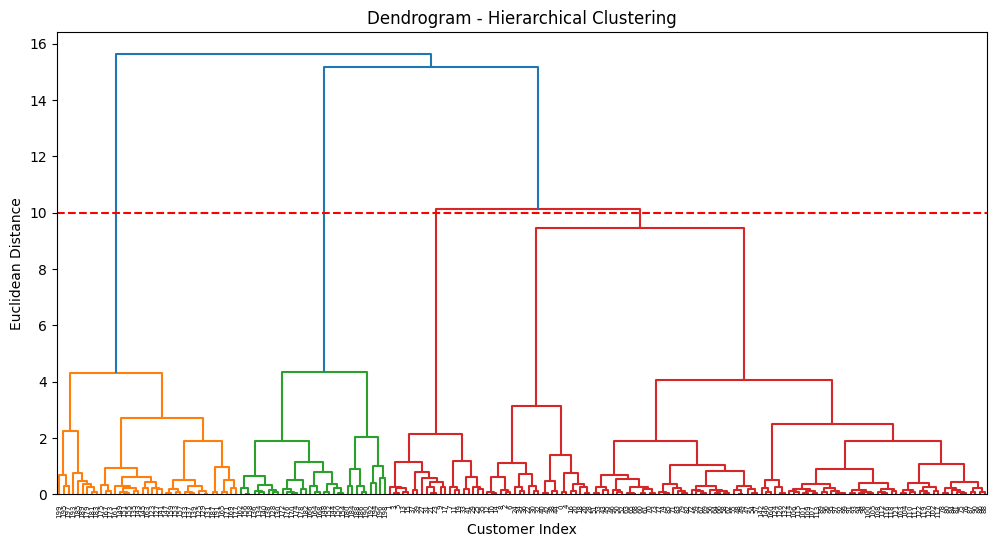

In [21]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# 10. Generate Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.axhline(y=10, color='r', linestyle='--')
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance')
plt.show()

In [24]:
from sklearn.cluster import AgglomerativeClustering

# 11. Create model
model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')

In [26]:
# 12. Fit and predict labels
y_hc = model.fit_predict(X_scaled)

In [27]:
# 13. Add prediction to dataframe
df['Cluster'] = y_hc
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


In [28]:
# 14. Count customers in each cluster
print(df['Cluster'].value_counts().sort_index())

Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64


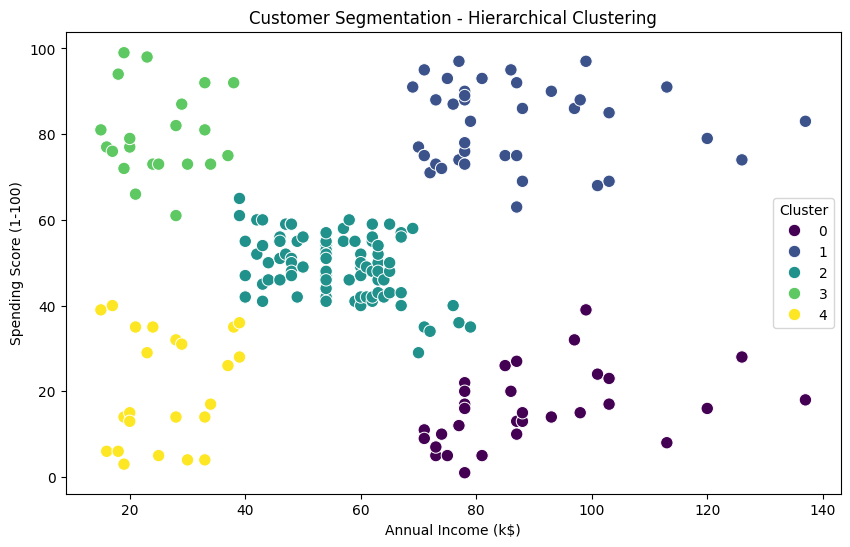

In [29]:
# 15. Create Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', s=80)
plt.title('Customer Segmentation - Hierarchical Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

In [30]:
# 16. Calculate average values
cluster_analysis = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_analysis)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 89.406250               15.593750
1                 86.538462               82.128205
2                 55.811765               49.129412
3                 25.095238               80.047619
4                 26.304348               20.913043
